# StatsBomb Event Data Exploration

This notebook explores StatsBomb Open Data using `statsbombpy`, performs basic exploratory data analysis (EDA), and creates common football analytics visualizations such as shot maps and pass maps.

> Note: You need network access and a compatible version of `statsbombpy` installed for the code cells to run successfully.


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch
from statsbombpy import sb

# Optional: ignore warnings from pandas/statsbombpy for a cleaner notebook
warnings.filterwarnings("ignore")

# Plotting defaults
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")

In [3]:
import pandas as pd

df = pd.read_csv(r"E:\Coding\football-analytics-ai\data\raw\comp_43_season_3\events_7585.csv")

df["type"].value_counts()

type
Pass               1161
Ball Receipt*      1066
Carry               851
Pressure            342
Ball Recovery       113
Duel                 62
Clearance            50
Goal Keeper          44
Block                43
Shot                 41
Miscontrol           36
Foul Committed       36
Foul Won             35
Dribble              29
Camera On            20
Dribbled Past        16
Dispossessed         14
Interception         12
Half End             10
Half Start           10
Substitution          8
Injury Stoppage       6
50/50                 4
Bad Behaviour         3
Starting XI           2
Camera off            2
Player Off            1
Player On             1
Tactical Shift        1
Name: count, dtype: int64

In [4]:
shots = df[df["type"] == "Shot"]

shots[[
    "player",
    "minute",
    "location",
    "shot_outcome",
    "shot_statsbomb_xg"
]].head()

,player,minute,location,shot_outcome,shot_statsbomb_xg
3817,Ashley Young,5,"[115.0, 18.0]",Saved,0.009816
3818,Raheem Sterling,7,"[112.0, 54.0]",Blocked,0.038204
3819,Raheem Sterling,12,"[98.0, 37.0]",Blocked,0.045128
3820,Harry Kane,15,"[119.0, 36.0]",Off T,0.625074
3821,Juan Guillermo Cuadrado Bello,21,"[97.0, 56.0]",Blocked,0.021760


In [5]:
pip install mplsoccer

Note: you may need to restart the kernel to use updated packages.


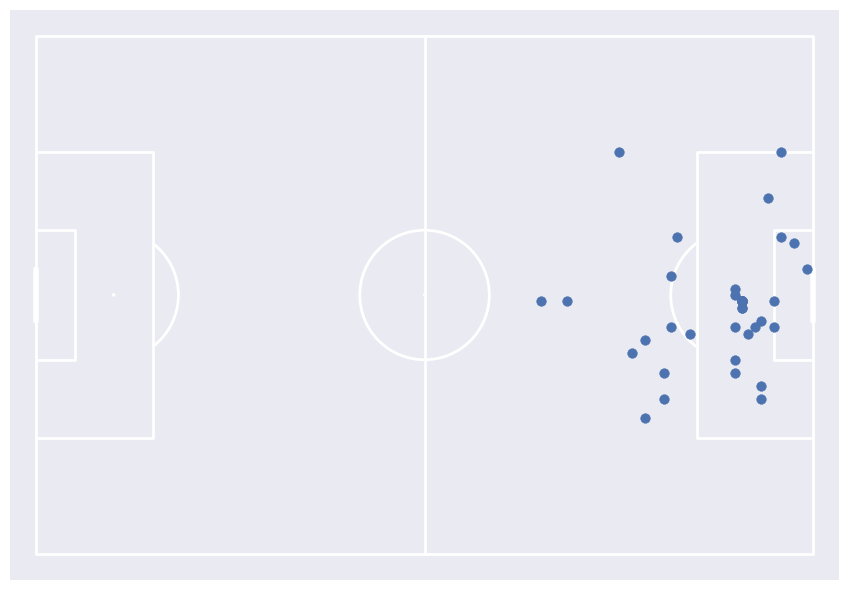

In [6]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch()
fig, ax = pitch.draw()

x = shots["location"].apply(lambda x: eval(x)[0])
y = shots["location"].apply(lambda x: eval(x)[1])

pitch.scatter(x, y, ax=ax)

plt.show()

In [7]:
pressures = df[df["type"] == "Pressure"]

pressing_intensity = len(pressures) / df["minute"].max()

print("Pressing intensity:", pressing_intensity)

Pressing intensity: 2.6929133858267718


In [8]:
from __future__ import annotations

from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd


def _get_col(df: pd.DataFrame, primary: str, fallback: str) -> str:
    """
    Return the name of the first column that exists in the DataFrame.
    """
    return primary if primary in df.columns else fallback


def _ensure_time_minutes(events: pd.DataFrame) -> pd.Series:
    """
    Approximate event time in minutes from StatsBomb `minute` and `second` columns.
    """
    minute = pd.to_numeric(events.get("minute", 0), errors="coerce").fillna(0)
    second = pd.to_numeric(events.get("second", 0), errors="coerce").fillna(0)
    return minute + second / 60.0


def compute_team_possession(events: pd.DataFrame) -> pd.Series:
    """
    Compute possession percentage per team.

    If `possession_team` is present, possession is based on the sum of
    event durations per possession team. Otherwise, it falls back to the
    share of total events per `team`/`team_name`.
    """
    if "possession_team" in events.columns:
        durations = pd.to_numeric(events.get("duration", 0), errors="coerce").fillna(0.0)
        poss_time = durations.groupby(events["possession_team"]).sum()
        total_time = poss_time.sum()
        if total_time > 0:
            possession_pct = poss_time / total_time * 100.0
        else:
            possession_pct = poss_time * 0.0
    else:
        team_col = _get_col(events, "team", "team_name")
        event_counts = events.groupby(team_col).size()
        total_events = event_counts.sum()
        possession_pct = event_counts / total_events * 100.0

    possession_pct.name = "possession_pct"
    return possession_pct


def compute_passes_and_pressures_per_minute(events: pd.DataFrame) -> pd.DataFrame:
    """
    Compute passes per minute and pressures per minute for each team.

    Minutes are approximated from the maximum event time in the match.
    """
    type_col = _get_col(events, "type", "type_name")
    team_col = _get_col(events, "team", "team_name")

    time_min = _ensure_time_minutes(events)
    total_minutes = float(time_min.max() + 1e-6)  # avoid division by zero

    passes = events[events[type_col].astype(str).str.contains("Pass", na=False)]
    pressures = events[events[type_col].astype(str).str.contains("Pressure", na=False)]

    passes_per_team = passes.groupby(team_col).size().rename("passes")
    pressures_per_team = pressures.groupby(team_col).size().rename("pressures")

    features = pd.concat([passes_per_team, pressures_per_team], axis=1).fillna(0)
    features["passes_per_min"] = features["passes"] / total_minutes
    features["pressures_per_min"] = features["pressures"] / total_minutes

    return features[["passes_per_min", "pressures_per_min"]]


def _compute_shot_distance(events: pd.DataFrame) -> pd.Series:
    """
    Compute shot distance from StatsBomb coordinates.

    Assumes the origin is at the bottom-left and the goal is centered at (120, 40).
    Coordinates are taken from `location` if present; otherwise this returns NaNs.
    """
    if "location" not in events.columns:
        return pd.Series(np.nan, index=events.index, name="shot_distance")

    loc = events["location"]

    # Handle both list-like and stringified lists
    def _to_xy(v):
        if isinstance(v, (list, tuple)) and len(v) >= 2:
            return float(v[0]), float(v[1])
        if isinstance(v, str) and v.startswith("[") and v.endswith("]"):
            try:
                x_str, y_str = v.strip("[]").split(",")[:2]
                return float(x_str), float(y_str)
            except Exception:
                return np.nan, np.nan
        return np.nan, np.nan

    xy = loc.map(_to_xy)
    xs = np.array([p[0] for p in xy])
    ys = np.array([p[1] for p in xy])

    goal_x, goal_y = 120.0, 40.0
    dist = np.sqrt((goal_x - xs) ** 2 + (goal_y - ys) ** 2)

    return pd.Series(dist, index=events.index, name="shot_distance")


def compute_shot_features(events: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average shot distance and total xG per team.
    """
    type_col = _get_col(events, "type", "type_name")
    team_col = _get_col(events, "team", "team_name")

    shots = events[events[type_col].astype(str).str.contains("Shot", na=False)].copy()
    if shots.empty:
        return pd.DataFrame(columns=["avg_shot_distance", "total_xg"])

    if "shot_statsbomb_xg" not in shots.columns:
        shots["shot_statsbomb_xg"] = np.nan

    shots["shot_distance"] = _compute_shot_distance(shots)

    grouped = shots.groupby(team_col).agg(
        avg_shot_distance=("shot_distance", "mean"),
        total_xg=("shot_statsbomb_xg", "sum"),
    )

    return grouped


def compute_team_features(events: pd.DataFrame) -> pd.DataFrame:
    """
    High-level helper to compute a set of team-level features:

    - possession percentage
    - passes per minute
    - pressures per minute
    - average shot distance
    - total xG

    Returns a DataFrame indexed by team name with one row per team.
    """
    team_col = _get_col(events, "team", "team_name")

    poss = compute_team_possession(events)
    tempo = compute_passes_and_pressures_per_minute(events)
    shots = compute_shot_features(events)

    features = pd.DataFrame(index=sorted(events[team_col].dropna().unique()))
    features = features.join(poss, how="left")
    features = features.join(tempo, how="left")
    features = features.join(shots, how="left")

    return features

In [9]:
import sys
from pathlib import Path

# Point directly to your project's src directory
project_src = Path(r"E:\Coding\football-analytics-ai\src")
sys.path.append(str(project_src))

import pandas as pd
from football_ai.preprocessing.feature_engineering import compute_team_features

from pathlib import Path
events_path = Path(r"E:\Coding\football-analytics-ai\data\raw\comp_43_season_3\events_7525.csv")

events = pd.read_csv(events_path)
team_features = compute_team_features(events)
print(team_features)

              possession_pct  passes_per_min  pressures_per_min  \
Russia             39.500171        4.092827           1.550633   
Saudi Arabia       60.499829        6.033755           1.276371   

              avg_shot_distance  total_xg  
Russia                17.957558  1.281601  
Saudi Arabia          22.460623  0.248806  


In [10]:
import pandas as pd
from pathlib import Path
from football_ai.preprocessing.feature_engineering import compute_team_features

# Example: single match
events = pd.read_csv(r"E:\Coding\football-analytics-ai\data\raw\comp_43_season_3\events_7525.csv")
team_features = compute_team_features(events)

# Add a simple label column (you must define this)
# e.g. from the scoreboard; here is a dummy example:
team_features = team_features.reset_index().rename(columns={"index": "team"})
team_features["match_id"] = 7525
team_features["result"] = ["win", "loss"]  # replace with real labels

out_path = Path("data") / "team_features.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
team_features.to_csv(out_path, index=False)
print(f"Saved team features to {out_path}")

Saved team features to data\team_features.csv


In [11]:
from pathlib import Path
import sys
import pandas as pd

project_src = Path.cwd() / "src"
if str(project_src) not in sys.path:
    sys.path.append(str(project_src))

from football_ai.preprocessing.feature_engineering import compute_team_features

events = pd.read_csv(r"E:\Coding\football-analytics-ai\data\raw\comp_43_season_3\events_7525.csv")
team_features = compute_team_features(events).reset_index().rename(columns={"index": "team"})
team_features["match_id"] = 7525
team_features["result"] = ["win", "loss"]  # replace with real labels

out_path = Path("data") / "team_features.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
team_features.to_csv(out_path, index=False)
print(out_path.resolve())

E:\Coding\football-analytics-ai\notebooks\data\team_features.csv


In [13]:
import pandas as pd
from football_ai.preprocessing.feature_engineering import compute_team_features

events = pd.read_csv("E:\\Coding\\football-analytics-ai\\data\\raw\\comp_43_season_3\\events_7525.csv")
team_features = compute_team_features(events)
print(team_features)

              possession_pct  passes_per_min  pressures_per_min  \
Russia             39.500171        4.092827           1.550633   
Saudi Arabia       60.499829        6.033755           1.276371   

              avg_shot_distance  total_xg  
Russia                17.957558  1.281601  
Saudi Arabia          22.460623  0.248806  


In [16]:
import pandas as pd

df["tactical_state"] = "unknown"
df.to_csv(r"E:\Coding\football-analytics-ai\data\raw\comp_43_season_3\events_7525_labeled.csv", index=False)
# Example dummy labeling: everything as 'unknown' or some heuristic
df["tactical_state"] = "unknown"  # or your own rule-based labels
df.to_csv("data/raw/comp_43_season_3/events_7525_labeled.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data\raw\comp_43_season_3'